# STA365 Homework 9

### Question 1

#### Q1 Part 2

For this question, I will be using the glass.csv dataset from: https://www.kaggle.com/datasets/uciml/glass.

In [2]:
import pandas
df = pandas.read_csv('glass.csv')
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


I will use the RI (refractive index) and Na (sodium) varialbles in my analysis, measuring their dependency structure using parameter rho.

In [3]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

In [3]:
# bivariate Gaussian copula with a rank-based transformation for the marginals

# the two variables of interest
ri = df["RI"].values
na = df["Na"].values

# transform the marginal distributions to uniform distributions by:
# sorting the data to get the ranks, then 
# divide the rank by total number of observations to get values between 0 and 1
u_ri = (np.argsort(np.argsort(ri)) + 1) / (len(ri) + 1)
u_na = (np.argsort(np.argsort(na)) + 1) / (len(na) + 1)

# convert uniform distributions to standard normal
z_ri = norm.ppf(u_ri)
z_na = norm.ppf(u_na)

# define and sample from the Gaussian Copula Model in PyMC
np.random.seed(365)

with pm.Model() as copula_model:
    # prior for correlation parameter (allowing near -1 to +1)
    rho = pm.Uniform("rho", lower=-0.99, upper=0.99)
    
    # log-likelihood for the bivariate Gaussian copula
    def log_lik(rho_val, z1, z2):
        # bivariate normal log PDF
        n = z1.shape[0]  # number of data points
        log_normalizing = -0.5 * np.log(2 * np.pi) - 0.5 * pm.math.log(1 - rho_val**2)
        exponent = -1.0 / (2 * (1 - rho_val**2)) * (z1**2 - 2 * rho_val * z1 * z2 + z2**2)
        
        # sum of log-likelihood over all pairs
        return n * log_normalizing + pm.math.sum(exponent)
    
    pm.Potential("likelihood", log_lik(rho, z_ri, z_na))
    
    # sample from posterior
    trace = pm.sample(
        draws=3000,       # total samples
        tune=1000,        # burn-in or "warm-up" period
        chains=4, 
        target_accept=0.9, # increase if there are many divergences
        random_seed=365
    )

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rho]


Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 3 seconds.


In [6]:
az.summary(trace, round_to=5)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
rho,-0.09554,0.06918,-0.21901,0.03949,0.00103,0.00065,4468.9956,5867.55209,1.00036


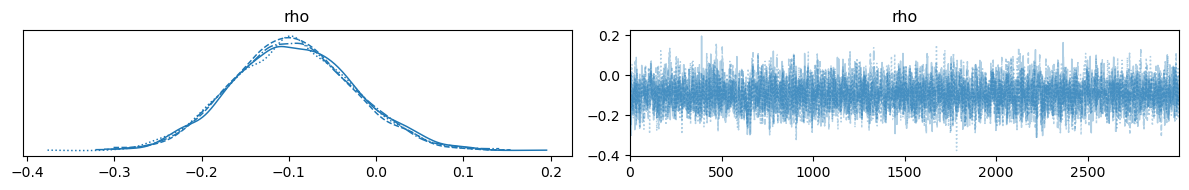

In [9]:
az.plot_trace(trace)
plt.tight_layout()
plt.show()

##### Posterior Inference

* The r_hat statistic for rho is less than 1.01 and is very close to 1, indicating the chains are mixing well and converging on the same result.
* From the trace plots above, we see that the chains are in agreement and have converged closely on the same result for rho.
* The ess_bulk statistic for rho is approximately 4,469, meaning that from our 12,000 total draws, we have the approximate equivalent of 4,469 independent samples. From the points above, it seems that this is a sufficient number of samples to have taken, as our diagnostics explained in the previous points suggest the chains have converged and have mixed well.
* The posterior mean of rho is approximately -0.096, which is very close to 0, suggesting that there is potentially a very weak negative dependence between RI (refractive index) and Na (sodium) on the Gaussian copula scale. The 94% HDI of (-0.21901, 0.03949), however, includes 0, meaning that there is possibly no correlation at all and the data does not provide strong evidence of a significant dependency between refractive index and sodium.

Overall, our analysis using a Bayesian copula shows that, on the Gaussian copula scale, this model has converged well and that the posterior inference does not provide strong evidence of a dependency between refractive index and sodium.

#### Q1 Part 3

A copula model is a statistical method that allows us to model the dependency structure between random variables through the use of copula functions. These functions can combine the individual marginal distributions of each variable to form the joint distribution, or dismantle the joint distribution into the marginal distributions it's composed of. This allows us to model both the joint distribution (how the variables interact together), as well as each component separately (how each variable behaves independently), providing inference on how the variables interact and their dependency.

Between the professor's method and the method suggested by PyMC, the prof's method is theoretically a better choice. The PyMC method uses a two pass approach where the marginals are first estimated and transformed, then the copula is estimated on these transformed values. The professor's method uses a fully Bayesian hierarchical model, estimating the marginal distributions and the copula at the same time. This joint estimation approach does a better job accounting for the uncertainty in the estimation of the marginals, as the PyMC method treats the marginal estimatations as fixed when estimating the copula, meaning any uncertainty in how the marginals were estimated is not carried into the dependency estimation. The prof's method, on the other hand, jointly estimates the marginal distributions and the copula, reflecting the uncertainties of both in the estimation of the dependency structure.

#### Q1 Part 4

Multivariate GLM regressions allow us to model multiple response variables simultaneously, while the copula captures the dependencies among these responses. We could use these methods to create arbitrary multivariate GLM regressions as a way to combine together separate GLMs for each outcome, while allowing the dependency structure to be modeled.

Using PyMC's version, we'd start by fitting separate GLMs for each outcome variable. Next, we'd use each model’s fitted CDF to transform the outcomes to a uniform scale, which reflects the estimated marginal behavior but ignores the uncertainty in their parameter estimates. Then, we would plug these estimated marginals into a copula model, to capture their dependency structure. Since this two pass approach treats the marginal estimations as fixed, however, any uncertainty in the GLM parameters is not carried forward into the copula estimation.

Using the professor's version, we'd start by defining a Bayesian hierarchical model that incorporates both the marginal GLMs and copula into one joint model. Each response would have its own GLM with its own parameters, likelihood, and priors. The copula would link these responses together and evaluate their dependancy structure. Since these steps are completed all at once, all the necessary uncertainty is captured, leading to more reliable inferences.

### Question 2

For this question, I will be using the Student_Performance.csv dataset from: https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression.

I will use "Hours Studied", "Previous Scores", "Extracurricular Activities", and "Sample Question Papers Practiced" to predict "Sleep Hours" and "Performance Index".

In [5]:
import pandas as pd
import numpy as np
import pymc as pm
from scipy import stats
import arviz as az
import matplotlib.pyplot as plt

df = pd.read_csv('Student_Performance.csv')
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [6]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].replace({'No': 0, 'Yes': 1})
df['Extracurricular Activities'] = df['Extracurricular Activities'].astype('int64')
#print(df.dtypes)

In [6]:
########################################################
#### Using spike and slab variable selection priors ####
########################################################

# predictor matrix (X), response matrix (Y)
predictors = ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sample Question Papers Practiced']
X = df[predictors].values  # shape (n_samples, n_predictors)
Y = df[['Performance Index', 'Sleep Hours']].values  # shape (n_samples, n_responses)

n, p = X.shape       # number of samples (n) and predictors (p)
q = Y.shape[1]       # number of response vars
np.random.seed(365)

with pm.Model() as marginal_spike_and_slab_model:
    # intercepts for each response variable
    intercept = pm.Normal("intercept", mu=0, sigma=2, shape=q)
    
    # hyperparameter --> prior probability of including a predictor
    pi = pm.Beta("pi", alpha=2, beta=2) # Beta prior on pi. pi is the prior probability of including a predictor
    
    slab = pm.Normal.dist(mu=0, sigma=2)
    spike = pm.Normal.dist(mu=0, sigma=0.01)
    
    beta = pm.Mixture(
        "beta",
        w=[pi, 1 - pi],  # spike is first component, slab is second component
        comp_dists=[spike, slab],
        shape=(p, q)
    )    
    
    # expected values
    mu = pm.math.dot(X, beta) + intercept  # shape (n_samples, n_responses)
    
    # likelihood
    sigma = pm.Exponential("sigma", lam=1, shape=q)
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=Y)
    
    # sample from posterior
    trace_marginal_spike_slab = pm.sample(draws=2000, tune=2000, target_accept=0.95, random_seed=365)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, pi, beta, sigma]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 166 seconds.


In [7]:
az.summary(trace_marginal_spike_slab, round_to=5)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"beta[0, 0]",2.85053,0.00845,2.83459,2.86599,0.00009,0.00009,8488.07137,6505.04502,1.00015
"beta[0, 1]",0.00080,0.00547,-0.00939,0.01104,0.00006,0.00006,8647.03592,6011.02624,1.00041
"beta[1, 0]",1.01788,0.00126,1.01565,1.02036,0.00002,0.00001,6155.58486,5977.79428,1.00077
"beta[1, 1]",0.00068,0.00097,-0.00110,0.00253,0.00001,0.00001,5283.24869,5472.68865,1.00003
"beta[2, 0]",0.56740,0.04342,0.48706,0.64908,0.00046,0.00049,9033.61652,6079.44400,1.00035
"beta[2, 1]",-0.02041,0.03300,-0.09660,0.01687,0.00121,0.00111,1340.56026,2253.19282,1.00338
"beta[3, 0]",0.19305,0.00772,0.17918,0.20777,0.00008,0.00008,9789.47012,5973.09096,0.99992
"beta[3, 1]",0.00203,0.00497,-0.00759,0.01111,0.00005,0.00006,8960.65311,6051.78461,1.00006
intercept[0],-30.85692,0.10853,-31.05473,-30.64799,0.00154,0.00110,4959.77357,5702.66040,1.00095
intercept[1],6.47989,0.08009,6.32437,6.62692,0.00122,0.00085,4313.84405,4981.33271,1.00022


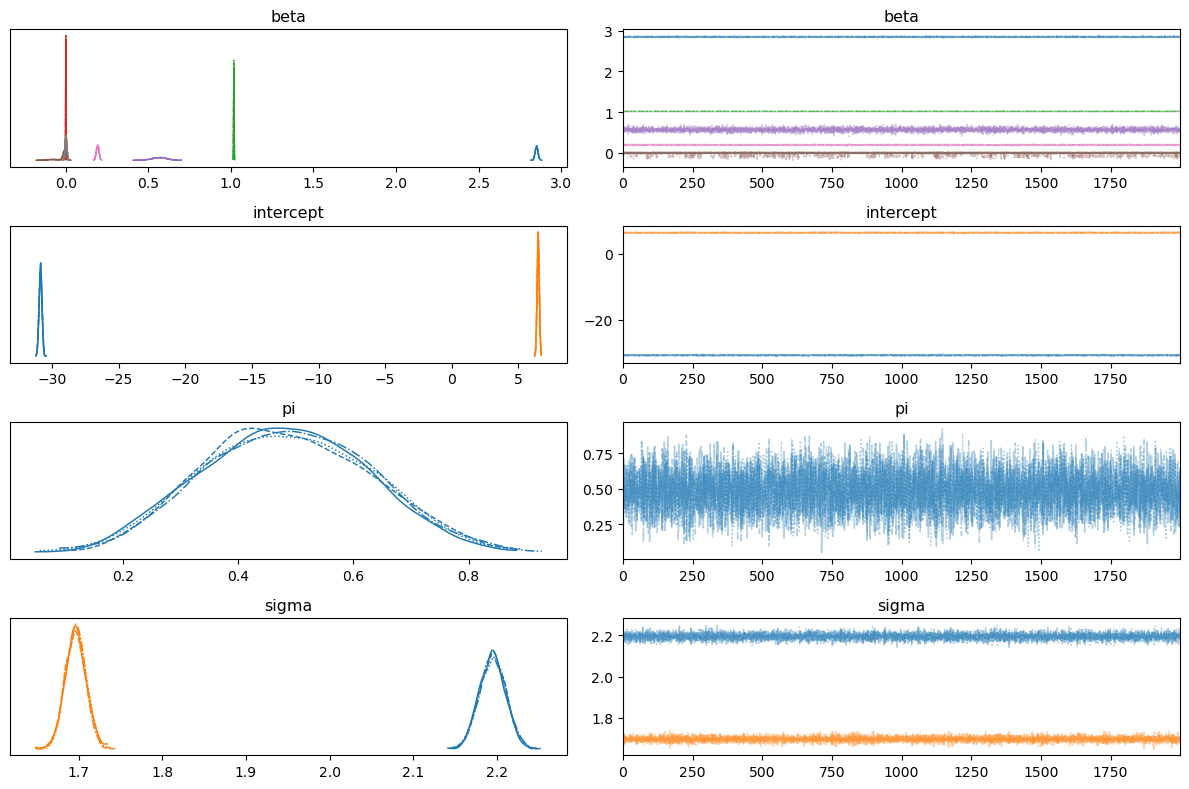

In [21]:
az.plot_trace(trace_marginal_spike_slab)
plt.tight_layout()
plt.show()

In [8]:
#####################################
#### Using diffuse normal priors ####
#####################################

np.random.seed(365)

with pm.Model() as diffuse_model:
    # intercepts for each response var
    intercept = pm.Normal("intercept", mu=0, sigma=2, shape=q)
    
    # normal priors for coefficients
    beta = pm.Normal("beta", mu=0, sigma=2, shape=(p, q))
    
    # expected values
    mu = pm.math.dot(X, beta) + intercept
    
    # likelihood
    sigma = pm.Exponential("sigma", lam=1, shape=q)
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=Y)
    
    trace_diffuse = pm.sample(draws=2000, tune=2000, target_accept=0.95, random_seed=365)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta, sigma]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 137 seconds.


In [23]:
az.summary(trace_diffuse, round_to=5)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"beta[0, 0]",2.85067,0.00850,2.83476,2.86687,0.00009,0.00009,8098.13977,5744.92518,1.00151
"beta[0, 1]",0.00123,0.00650,-0.01062,0.01366,0.00007,0.00007,9185.07833,6146.72473,1.00046
"beta[1, 0]",1.01786,0.00126,1.01552,1.02021,0.00002,0.00001,5900.41474,6048.14160,1.00149
"beta[1, 1]",0.00070,0.00098,-0.00111,0.00253,0.00001,0.00001,4983.66490,5019.96619,1.00029
"beta[2, 0]",0.56731,0.04393,0.48379,0.65059,0.00046,0.00046,9320.06144,6560.11790,0.99992
"beta[2, 1]",-0.07801,0.03379,-0.13931,-0.01229,0.00039,0.00038,7629.11858,5789.33195,1.00074
"beta[3, 0]",0.19301,0.00757,0.17915,0.20730,0.00008,0.00008,8703.25809,6218.78728,0.99989
"beta[3, 1]",0.00280,0.00590,-0.00818,0.01395,0.00007,0.00006,7370.58857,5751.73483,1.00037
intercept[0],-30.85562,0.10702,-31.05708,-30.65215,0.00155,0.00115,4737.87349,5670.56240,1.00010
intercept[1],6.50104,0.08273,6.34241,6.64958,0.00126,0.00092,4340.91644,5239.06474,1.00030


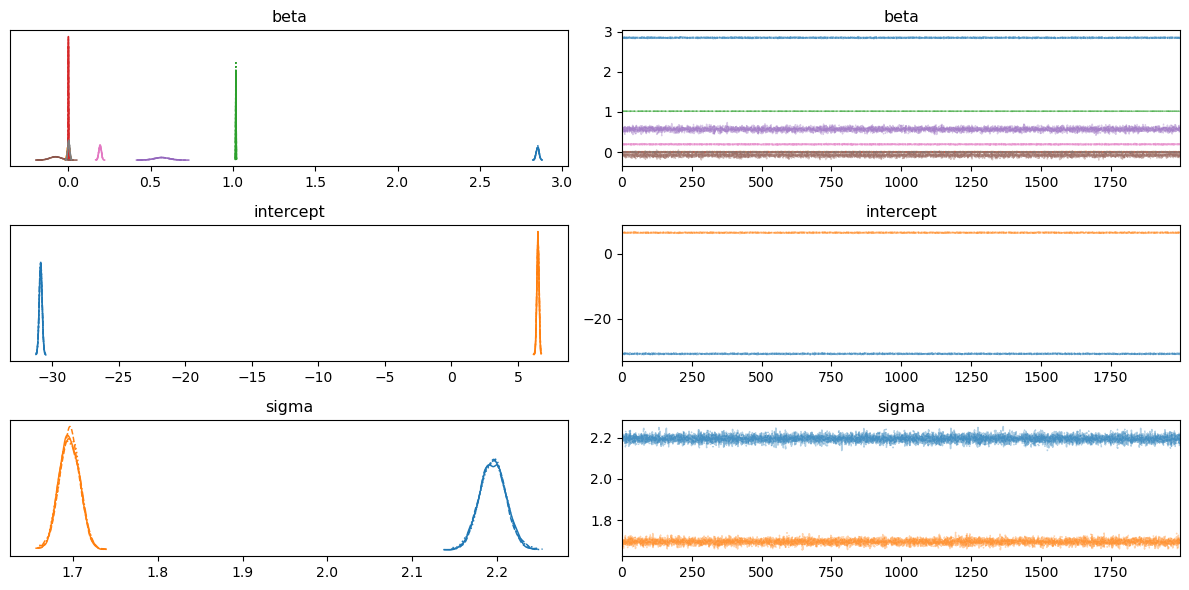

In [24]:
az.plot_trace(trace_diffuse)
plt.tight_layout()
plt.show()

#### Comparison of the two methods:

* The r_hat statistics for all parameters in both models are less than 1.01 and are very close to 1, indicating the chains are mixing well and converging on the same results.
* From the trace plots of both models above, we see that the chains for each parameter are in agreement and have converged closely on the same result. We also see that the trace plots follow the same pattern and look very similar between the two models.
* All coefficients have nearly the same values between the two models, suggesting that for this example, the data provides clear evidence about the coefficient values. It makes sense that since we are using 10,000 data points, the likelihood overwhelms the prior, so both the spike and slab and diffuse models result in similar posterior estimates. Since both models agree, this suggests the predictors and their relationship with the response variables can be measured by the data alone. For this example then, variable selection aspect of the spike and slab model isn’t needed, as the data is already enough to indicate the importance of each variable.
* The only coefficient with a slight discrepancy between the two models is beta[2, 1]. In the spike and slab model, the posterior mean of beta[2, 1] is -0.02041 with 94% HDI (-0.09660, 0.01687). This HDI includes zero, indicating the model is uncertain about whether this coefficient should truly be negative or not, so the model might be shrinking this coefficient closer to zero just in case. With the diffuse normal prior model, however, the posterior mean of beta[2, 1] is -0.07801 with 94% HDI (-0.13931, -0.01229). This HDI does not include zero, suggesting slightly more evidence of a small negative effect that is not seen in the spike and slab model. This makes sense, as the data suggests beta[2, 1] is fairly close to zero, so in the spike and slab model, the model places this coefficient near the spike. The diffuse normal prior model does not do this step, and allows for a small but consistently negative coefficient, so since the data suggests a slight negative effect, it makes sense that its 94% HDI does not include zero.





### Question 3

As in question 2, I will be using the Student_Performance.csv dataset from: https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression.

I will again use "Hours Studied", "Previous Scores", "Extracurricular Activities", and "Sample Question Papers Practiced" to predict "Sleep Hours" and "Performance Index".

In [12]:
predictors = ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sample Question Papers Practiced']
X = df[predictors].values
Y = df[["Performance Index", "Sleep Hours"]].values
n, p = X.shape
q = Y.shape[1]
np.random.seed(365)

with pm.Model() as horseshoe_model:
    # intercepts for each response var
    intercept = pm.Normal("intercept", mu=0, sigma=2, shape=q)
    
    # global shrinkage parameter (tau), common across predictors and responses
    # Half-Cauchy is common for horseshoe priors
    tau = pm.HalfCauchy("tau", beta=1)
    
    # local shrinkage parameters for each predictor-response pair
    lam = pm.HalfCauchy("lam", beta=1, shape=(p, q))
    
    # horseshoe prior for regression coefficients
    # each beta coefficient is drawn from a Normal with mean 0 and standard deviation tau * lam.
    beta = pm.Normal("beta", mu=0, sigma=tau * lam, shape=(p, q))
    
    # expected value
    mu = pm.math.dot(X, beta) + intercept
    
    # standard deviations (noise) for each response variable
    sigma = pm.Exponential("sigma", lam=1, shape=q)
    
    # likelihood
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=Y)
    
    # sampling from posterior
    trace_horseshoe1 = pm.sample(draws=2000, tune=2000, target_accept=0.95, random_seed=365, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, tau, lam, beta, sigma]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 501 seconds.
There were 131 divergences after tuning. Increase `target_accept` or reparameterize.


In [13]:
az.summary(trace_horseshoe1, round_to=5)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"beta[0, 0]",2.85048,0.00852,2.83495,2.86682,0.00010,0.00010,7476.54530,5516.51656,1.00054
"beta[0, 1]",0.00095,0.00591,-0.01099,0.01176,0.00007,0.00008,6877.58627,4844.06006,1.00059
"beta[1, 0]",1.01783,0.00126,1.01532,1.02007,0.00002,0.00002,5589.80759,2443.74107,1.00106
"beta[1, 1]",0.00061,0.00092,-0.00106,0.00241,0.00001,0.00001,5383.51046,4419.32361,1.00044
"beta[2, 0]",0.56285,0.04477,0.48160,0.65190,0.00049,0.00056,8169.33773,5239.77924,1.00045
"beta[2, 1]",-0.06676,0.03561,-0.12957,0.00317,0.00047,0.00040,5780.45428,5165.15159,1.00077
"beta[3, 0]",0.19273,0.00766,0.17858,0.20701,0.00008,0.00009,9495.77366,5003.42375,1.00043
"beta[3, 1]",0.00220,0.00544,-0.00822,0.01256,0.00006,0.00007,7834.85855,5674.21487,1.00041
intercept[0],-30.84897,0.10799,-31.04382,-30.63682,0.00150,0.00127,5219.59971,2053.58188,1.00125
intercept[1],6.50589,0.07824,6.35703,6.64976,0.00113,0.00092,4819.34597,4674.24072,1.00086


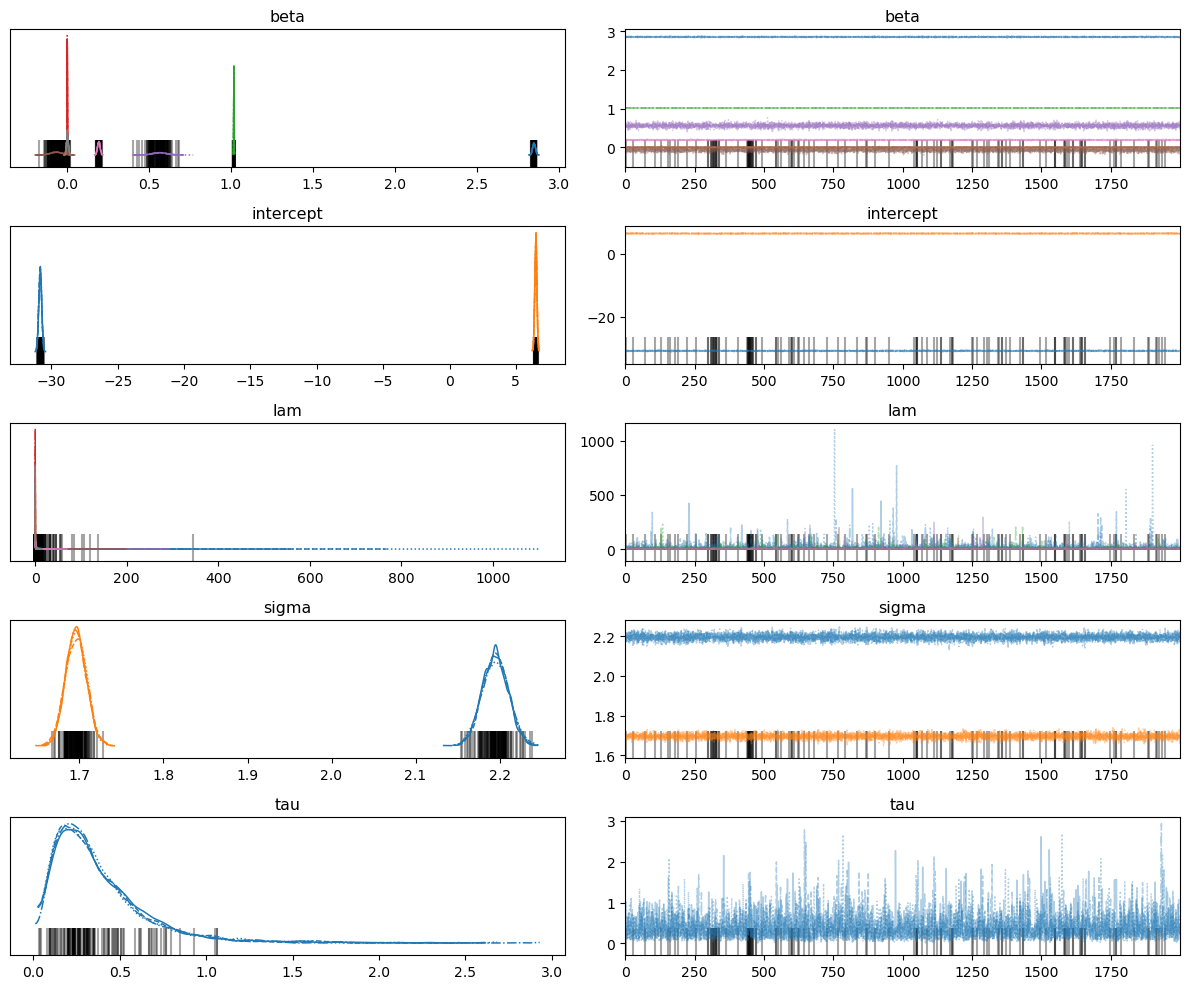

In [14]:
az.plot_trace(trace_horseshoe1)
plt.tight_layout()
plt.show()

#### Spike and Slab Priors (from Q2) vs Horseshoe Variable Selection Prior

* The r_hat statistics for all parameters in both models are less than 1.01 and are very close to 1, indicating the chains are mixing well and converging on the same results.
* ess_bulk values for all parameters in both cases are in the thousands and seem sufficiently large to provide reliable inference, judging from our other diagnostics.
* Looking at the az.summary of both models, we see that the posterior mean and 94% HDIs of the betas, intercepts, and sigma estimated are nearly identical. In addition, the traces plots of beta, intercept, and sigma are nearly ideantical between the two models, other than the divergences encountered when using the Horseshoe Variable Selection Prior. This suggests that the data is highly informative and overwhelms the priors in both modles, making the prior we choose in this case not as important. This makes sense as our dataset has 10,000 data points, and I included them all in this analysis.
* The 131 divergences of the horseshoe prior are likely due to the fact that it uses Half-Cauchy distributions for the global and local scales. These are heavy-tailed distributions that allow for extreme values, which can lead to regions in the posterior with steep curves which will be more difficult for the sampler to navigate, leading to divergences.

Overall, we can conclude that both the spike and slab and the horseshoe variable selection priors yield very similar inferences in this example.